In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
import math
import pandas as pd

In [2]:
#create cities and connections
citynet = nx.complete_graph(100)

"""
route_names = ('airline,airline_id,'
         'source,source_id,'
         'dest,dest_id,'
         'codeshare,stops,equipment').split(',')

routes = pd.read_csv(
    'https://github.com/ipython-books/'
    'cookbook-2nd-data/blob/master/'
    'routes.dat?raw=true',
    names=route_names,
    header=None)

airport_names = ('id,name,city,country,iata,icao,lat,lon,'
         'alt,timezone,dst,tz,type,source').split(',')

airports = pd.read_csv(
    'https://github.com/ipython-books/'
    'cookbook-2nd-data/blob/master/'
    'airports.dat?raw=true',
    header=None,
    names=airport_names,
    index_col=4,
    na_values='\\N')
some_airports = airports[airports['country'].isin(['Russia']) & (~airports.index.isna())]
some_routes = routes[
    routes['source'].isin(some_airports.index) &
    routes['dest'].isin(some_airports.index)]
edges = some_routes[['source', 'dest']].values
citynet = nx.from_edgelist(edges)

#choose epidemic's parameters
b = 2
y = 1
cs0 = random.choice(list(citynet.nodes()))
"""
cs0 = list(citynet.nodes)[1]

In [3]:

'''
for node in citynet.nodes():

  if node in reds:
    citynet.nodes[node]['color'] = 'red'
  else:
    citynet.nodes[node]['color'] = 'blue'
node_colors = [citynet.nodes[node]['color'] for node in citynet.nodes]
nx.draw(citynet, with_labels = True, node_color = node_colors , node_size = 25)

print(len(list(citynet.nodes)))
'''

"\nfor node in citynet.nodes():\n\n  if node in reds:\n    citynet.nodes[node]['color'] = 'red'\n  else:\n    citynet.nodes[node]['color'] = 'blue'\nnode_colors = [citynet.nodes[node]['color'] for node in citynet.nodes]\nnx.draw(citynet, with_labels = True, node_color = node_colors , node_size = 25)\n\nprint(len(list(citynet.nodes)))\n"

In [4]:
#function for many graphics
def run_epi(graph, b, y, cs0):
    reds = set()
    blues = set(graph.nodes)
    blue_ns = list()
    times = list()
    times.append(0)
    greens = set()
    reds.add(cs0)
    blues.remove(cs0)
    st = [len(blues)]
    it = [1]
    rt = [0]
    #initialization of epidemic
    reds = set()
    blues = set(graph.nodes)
    blue_ns = list()
    times = list()
    times.append(0)
    greens = set()

    reds.add(cs0)
    blues.remove(cs0)
    st = [len(blues)]
    it = [1]
    rt = [0]         

    while True:
        blue_ns = []
        for red in reds:
            for neighbor in graph.neighbors(red):
                if neighbor in blues:
                    blue_ns.append(neighbor)
        ne = len(blue_ns)
        i = len(reds)
        pi = b * ne / (b * ne + i * y)
        pr = y * i / (b * ne + i * y)
        dtime = 1 / (b * ne + i * y) * math.log(1./random.random())
        chance = random.random()

        if chance <= pi:
            new_red = random.choice(blue_ns)
            reds.add(new_red)
            blues.remove(new_red)
            blue_ns.remove(new_red)
        else:
            new_green = random.choice(list(reds))
            reds.remove(new_green)
            greens.add(new_green)
        times.append(times[-1] + dtime)
        st.append(len(blues))
        it.append(len(reds))
        rt.append(len(greens))
        if len(reds) == 0:
            break

    return(np.array(times), st, it, rt)

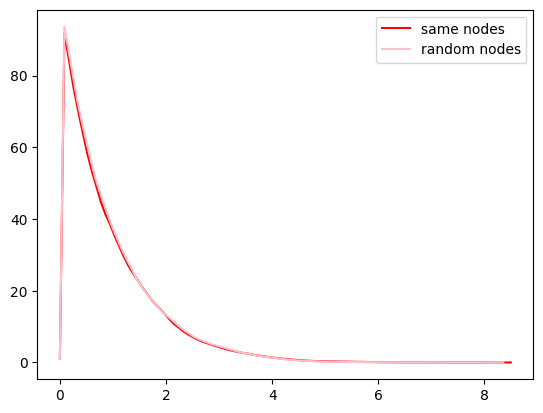

In [5]:
def do_mean_stand(graph,var):
    num_gr = 50
    defres = []
    timeslist = []
    if var == 'random':
        for i in range(num_gr):
            defres.append(run_epi(graph, 2, 1, random.choice(list(citynet.nodes))))
            timeslist.append(defres[-1][0][-1])
            maxtime = max(timeslist)
            divider = 100
            abstimes = np.linspace(0, maxtime, divider)
            news = np.empty((num_gr, divider))
            newi = np.empty((num_gr, divider))
            newr = np.empty((num_gr, divider))
    elif var == 'same':
        for i in range(num_gr):
            defres.append(run_epi(graph, 2, 1, cs0))
            timeslist.append(defres[-1][0][-1])
            maxtime = max(timeslist)
            divider = 100
            abstimes = np.linspace(0, maxtime, divider)
            news = np.empty((num_gr, divider))
            newi = np.empty((num_gr, divider))
            newr = np.empty((num_gr, divider))
    for j in range(num_gr):
        news[j] = np.interp(abstimes, defres[j][0], defres[j][1], right = defres[j][1][-1]
        )
        newi[j] = np.interp(abstimes, defres[j][0], defres[j][2], right = defres[j][2][-1]
        )
        newr[j] = np.interp(abstimes, defres[j][0], defres[j][3], right = defres[j][3][-1]
        )

    avers = np.mean(news, axis = 0)
    averi = np.mean(newi, axis = 0)
    averr = np.mean(newr, axis = 0)
    return(abstimes, averi, newi)

defres2 = do_mean_stand(citynet,'same')
plt.plot(defres2[0], defres2[1], color = 'red',label='same nodes')
defres3 = do_mean_stand(citynet,'random') 
plt.plot(defres3[0], defres3[1], color = 'pink', label = 'random nodes')
plt.legend()

In [6]:
'''
standarts = news.std(axis = 0)
standartr = newr.std(0)
plt.figure(figsize = (10, 10))
plt.plot(abstimes,avers, color = 'black')
plt.plot(abstimes,averi,color = 'black')
plt.plot(abstimes,averr,color = 'black')
for i in range(50):
    plt.plot(abstimes, news[i, :], color = 'blue', alpha = 0.4)
    plt.plot(abstimes, newi[i, :], color = 'red', alpha = 0.4)
    plt.plot(abstimes, newr[i, :], color = 'green', alpha = 0.4)
plt.fill_between(abstimes, avers - standarts, avers + standarts,alpha = 0.3)
plt.fill_between(abstimes, averr - standartr, averr + standartr, alpha = 0.3)
''' 

"\nstandarts = news.std(axis = 0)\nstandartr = newr.std(0)\nplt.figure(figsize = (10, 10))\nplt.plot(abstimes,avers, color = 'black')\nplt.plot(abstimes,averi,color = 'black')\nplt.plot(abstimes,averr,color = 'black')\nfor i in range(50):\n    plt.plot(abstimes, news[i, :], color = 'blue', alpha = 0.4)\n    plt.plot(abstimes, newi[i, :], color = 'red', alpha = 0.4)\n    plt.plot(abstimes, newr[i, :], color = 'green', alpha = 0.4)\nplt.fill_between(abstimes, avers - standarts, avers + standarts,alpha = 0.3)\nplt.fill_between(abstimes, averr - standartr, averr + standartr, alpha = 0.3)\n"

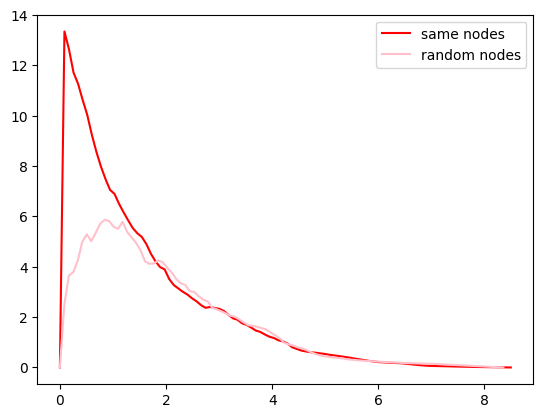

In [7]:
standarti_same = defres2[2].std(0)
standarti_random = defres3[2].std(0)
plt.plot(defres2[0], standarti_same, color = 'red', label = 'same nodes')
plt.plot(defres3[0], standarti_random, color = 'pink', label = 'random nodes')
plt.legend()